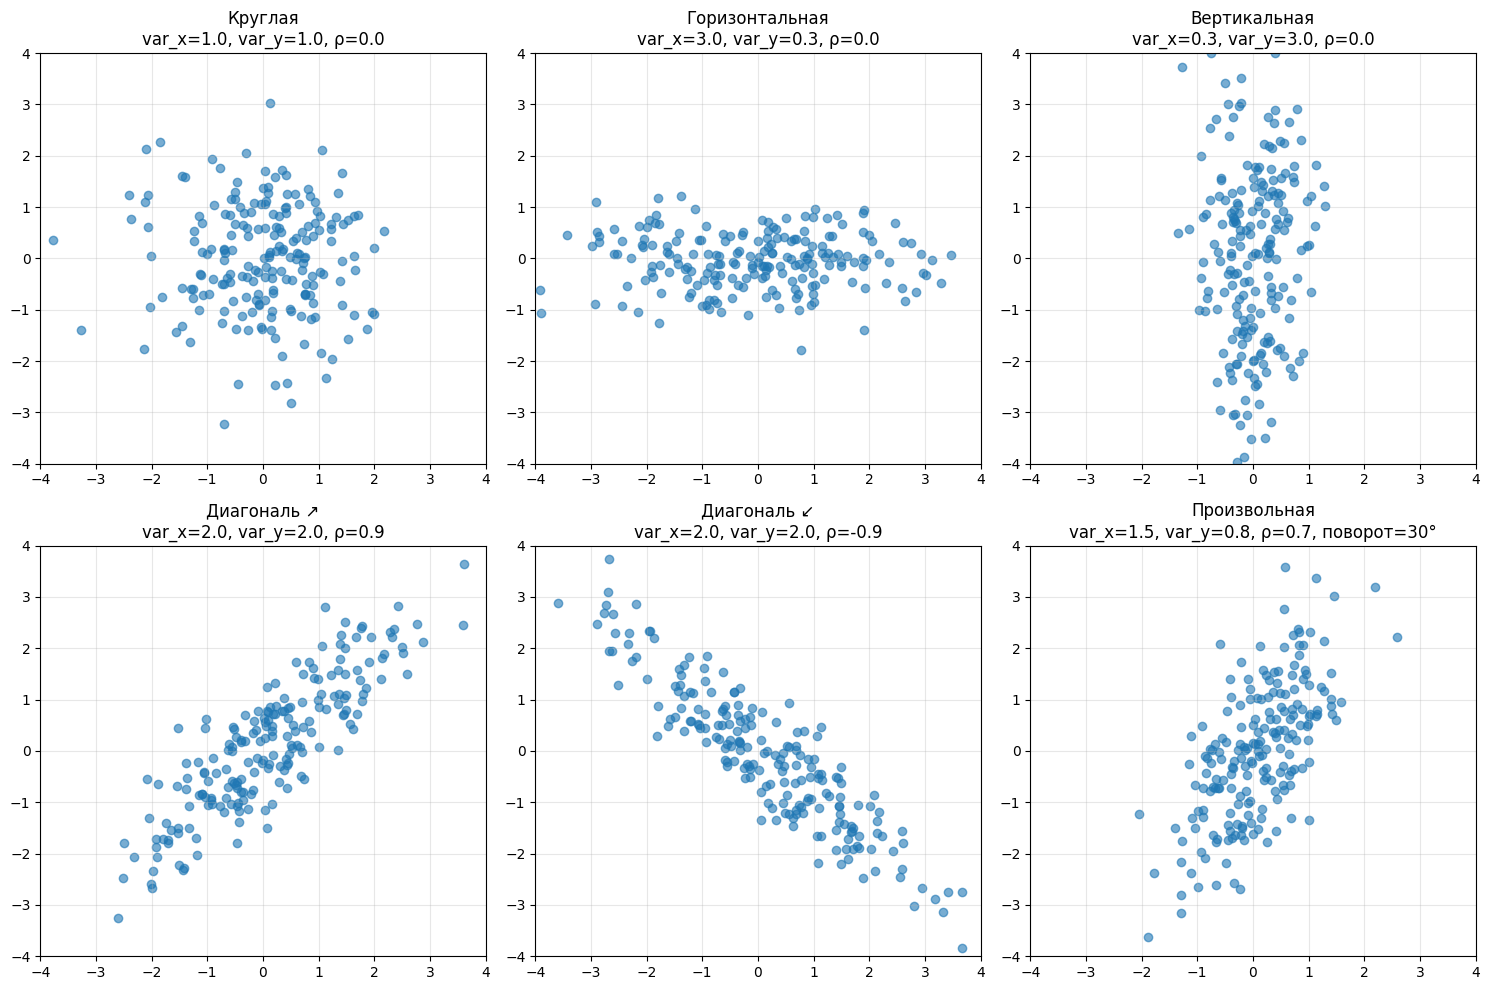

=== КАК УПРАВЛЯТЬ ТУЧКОЙ ===
РАСТЯЖЕНИЕ:
  var_x > var_y - вытянута по горизонтали
  var_x < var_y - вытянута по вертикали
  var_x = var_y - симметричная

ОРИЕНТАЦИЯ:
  ρ > 0 - вытянута по диагонали ↗
  ρ < 0 - вытянута по диагонали ↙
  ρ = 0 - оси совпадают с координатными

РАЗМЕР:
  var_x, var_y большие - большая тучка
  var_x, var_y малые - маленькая тучка

ПРИМЕРЫ:
  Овал по горизонтали: var_x=3.0, var_y=0.5, ρ=0.0
  Овал по вертикали: var_x=0.5, var_y=3.0, ρ=0.0
  Диагональ ↗: var_x=2.0, var_y=2.0, ρ=0.9
  Диагональ ↙: var_x=2.0, var_y=2.0, ρ=-0.9


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# ==================== БАЗОВЫЕ ПАРАМЕТРЫ ТУЧКИ ====================

M = np.array([0.0, 0.0])  # Центр тучки

# Ковариационная матрица в общем виде:
# B = [[σ_x²,     ρσ_xσ_y],
#      [ρσ_xσ_y, σ_y²    ]]

# ==================== ПРИМЕРЫ УПРАВЛЕНИЯ ТУЧКОЙ ====================

# 1. КРУГЛАЯ тучка (изотропная)
B_circle = np.array([[1.0, 0.0],
                     [0.0, 1.0]])

# 2. ВЫТЯНУТА по горизонтали
B_horizontal = np.array([[2.0, 0.0],   # σ_x² = 2.0 (большая дисперсия по x)
                         [0.0, 0.5]])  # σ_y² = 0.5 (малая дисперсия по y)

# 3. ВЫТЯНУТА по вертикали  
B_vertical = np.array([[0.5, 0.0],     # σ_x² = 0.5 (малая дисперсия по x)
                       [0.0, 2.0]])    # σ_y² = 2.0 (большая дисперсия по y)

# 4. ВЫТЯНУТА по диагонали ↗ (положительная корреляция)
B_diag_up = np.array([[1.5, 1.2],      # ρ ≈ 0.8 (сильная положительная корреляция)
                      [1.2, 1.5]])

# 5. ВЫТЯНУТА по диагонали ↙ (отрицательная корреляция)
B_diag_down = np.array([[1.5, -1.2],   # ρ ≈ -0.8 (сильная отрицательная корреляция)
                        [-1.2, 1.5]])

# ==================== ФУНКЦИЯ ДЛЯ СОЗДАНИЯ ТУЧЕК ====================

def create_cloud(center, var_x, var_y, correlation, rotation_angle=0):
    """
    Создает ковариационную матрицу для тучки
    
    Parameters:
    center - центр тучки [x, y]
    var_x - дисперсия по оси x (растяжение по горизонтали)
    var_y - дисперсия по оси y (растяжение по вертикали) 
    correlation - корреляция между x и y (-1 до 1)
    rotation_angle - угол поворота в градусах
    """
    # Базовая ковариационная матрица
    cov_xy = correlation * np.sqrt(var_x * var_y)
    B = np.array([[var_x, cov_xy],
                  [cov_xy, var_y]])
    
    # Поворот матрицы (опционально)
    if rotation_angle != 0:
        theta = np.radians(rotation_angle)
        R = np.array([[np.cos(theta), -np.sin(theta)],
                      [np.sin(theta), np.cos(theta)]])
        B = R @ B @ R.T
    
    return B

# ==================== ДЕМОНСТРАЦИЯ ====================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Круглая тучка
B1 = create_cloud(M, var_x=1.0, var_y=1.0, correlation=0.0)
X1 = np.random.multivariate_normal(M, B1, 200)
axes[0,0].scatter(X1[:,0], X1[:,1], alpha=0.6)
axes[0,0].set_title('Круглая\nvar_x=1.0, var_y=1.0, ρ=0.0')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xlim(-4, 4); axes[0,0].set_ylim(-4, 4)

# 2. Горизонтальная
B2 = create_cloud(M, var_x=3.0, var_y=0.3, correlation=0.0)
X2 = np.random.multivariate_normal(M, B2, 200)
axes[0,1].scatter(X2[:,0], X2[:,1], alpha=0.6)
axes[0,1].set_title('Горизонтальная\nvar_x=3.0, var_y=0.3, ρ=0.0')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_xlim(-4, 4); axes[0,1].set_ylim(-4, 4)

# 3. Вертикальная
B3 = create_cloud(M, var_x=0.3, var_y=3.0, correlation=0.0)
X3 = np.random.multivariate_normal(M, B3, 200)
axes[0,2].scatter(X3[:,0], X3[:,1], alpha=0.6)
axes[0,2].set_title('Вертикальная\nvar_x=0.3, var_y=3.0, ρ=0.0')
axes[0,2].grid(True, alpha=0.3)
axes[0,2].set_xlim(-4, 4); axes[0,2].set_ylim(-4, 4)

# 4. Диагональ ↗
B4 = create_cloud(M, var_x=2.0, var_y=2.0, correlation=0.9)
X4 = np.random.multivariate_normal(M, B4, 200)
axes[1,0].scatter(X4[:,0], X4[:,1], alpha=0.6)
axes[1,0].set_title('Диагональ ↗\nvar_x=2.0, var_y=2.0, ρ=0.9')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_xlim(-4, 4); axes[1,0].set_ylim(-4, 4)

# 5. Диагональ ↙
B5 = create_cloud(M, var_x=2.0, var_y=2.0, correlation=-0.9)
X5 = np.random.multivariate_normal(M, B5, 200)
axes[1,1].scatter(X5[:,0], X5[:,1], alpha=0.6)
axes[1,1].set_title('Диагональ ↙\nvar_x=2.0, var_y=2.0, ρ=-0.9')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_xlim(-4, 4); axes[1,1].set_ylim(-4, 4)

# 6. Произвольная
B6 = create_cloud(M, var_x=1.5, var_y=0.8, correlation=0.7, rotation_angle=30)
X6 = np.random.multivariate_normal(M, B6, 200)
axes[1,2].scatter(X6[:,0], X6[:,1], alpha=0.6)
axes[1,2].set_title('Произвольная\nvar_x=1.5, var_y=0.8, ρ=0.7, поворот=30°')
axes[1,2].grid(True, alpha=0.3)
axes[1,2].set_xlim(-4, 4); axes[1,2].set_ylim(-4, 4)

plt.tight_layout()
plt.show()

# ==================== ШПАРГАЛКА ====================

print("=== КАК УПРАВЛЯТЬ ТУЧКОЙ ===")
print("РАСТЯЖЕНИЕ:")
print("  var_x > var_y - вытянута по горизонтали") 
print("  var_x < var_y - вытянута по вертикали")
print("  var_x = var_y - симметричная")

print("\nОРИЕНТАЦИЯ:")
print("  ρ > 0 - вытянута по диагонали ↗")
print("  ρ < 0 - вытянута по диагонали ↙") 
print("  ρ = 0 - оси совпадают с координатными")

print("\nРАЗМЕР:")
print("  var_x, var_y большие - большая тучка")
print("  var_x, var_y малые - маленькая тучка")

print("\nПРИМЕРЫ:")
print("  Овал по горизонтали: var_x=3.0, var_y=0.5, ρ=0.0")
print("  Овал по вертикали: var_x=0.5, var_y=3.0, ρ=0.0")
print("  Диагональ ↗: var_x=2.0, var_y=2.0, ρ=0.9")
print("  Диагональ ↙: var_x=2.0, var_y=2.0, ρ=-0.9")